In [2]:
!pip install findspark pyspark textblob pandas


^C


In [2]:
import re
import findspark
findspark.init()
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import udf, col
from pyspark.sql.types import StringType
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt

In [3]:
spark = SparkSession.builder \
    .appName("BigData_Twitter_Sentiment") \
    .config("spark.ui.showConsoleProgress", "false") \
    .getOrCreate()

print(" Spark Session Initialized")

 Spark Session Initialized


In [7]:
df = pd.read_csv("/content/Twitter.csv", encoding='latin1', header=None)
df.columns = ['target', 'id', 'date', 'flag', 'user', 'text']
df['target'] = df['target'].replace(4, 1)  # Convert 4 → Positive (1)

# Convert Pandas → Spark
data = spark.createDataFrame(df[['target', 'text']])
print(f" Data Loaded Successfully: {data.count()} rows")

 Data Loaded Successfully: 1600000 rows


In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

clean_udf = udf(clean_text, StringType())
data = data.withColumn("clean_text", clean_udf(col("text")))

In [9]:
tokenizer = Tokenizer(inputCol="clean_text", outputCol="words")
remover = StopWordsRemover(inputCol="words", outputCol="filtered")
tf = HashingTF(inputCol="filtered", outputCol="raw_features", numFeatures=5000)
idf = IDF(inputCol="raw_features", outputCol="features")
lr = LogisticRegression(featuresCol="features", labelCol="target", maxIter=20)

pipeline = Pipeline(stages=[tokenizer, remover, tf, idf, lr])

In [10]:
train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)
model=pipeline.fit(train_data)
print ("Model Training Completed")

Model Training Completed


In [11]:
predictions = model.transform(test_data)

evaluator = MulticlassClassificationEvaluator(
    labelCol="target", predictionCol="prediction", metricName="accuracy"
)
accuracy = evaluator.evaluate(predictions)
print(f" Model Accuracy: {accuracy:.4f}")


 Model Accuracy: 0.7472


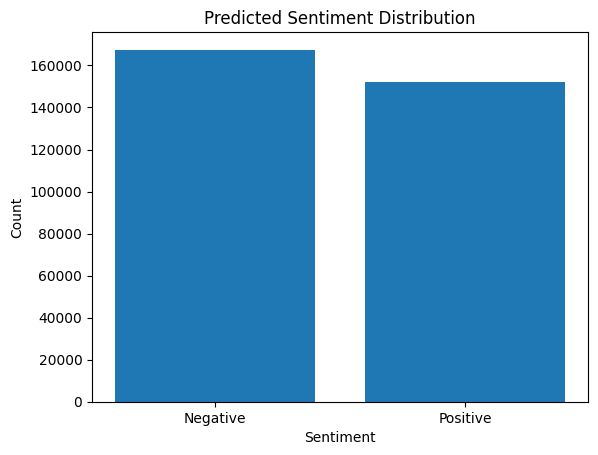

In [12]:
pred_pd = predictions.select("target", "prediction").toPandas()
counts = pred_pd["prediction"].value_counts()

plt.bar(["Negative", "Positive"], counts)
plt.title("Predicted Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [1]:
def predict_sentiment(text):
    sample_df = spark.createDataFrame([(0, text)], ["target", "text"])
    sample_df = sample_df.withColumn("clean_text", clean_udf(col("text")))
    result = model.transform(sample_df).select("prediction").collect()[0][0]
    sentiment = "Positive 😊" if result == 1 else "Negative 😠"
    print(f"\nTweet: {text}\nPrediction: {sentiment}")

# Test Examples
predict_sentiment("I love how smooth the new iPhone feels!")
predict_sentiment("This movie was boring and a waste of time.")

print("\n✅ Big Data Twitter Sentiment Analysis Completed Successfullly!")

NameError: name 'spark' is not defined